In [1]:
# ─────────────────────────────────────────────────────────────
# IMPORTANT: tell Python where to find the src/ folder
# Our notebook is inside notebooks/ — src/ is one level above
# ─────────────────────────────────────────────────────────────
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

print('Path set. Python will now look in:', os.path.abspath('..'))

Path set. Python will now look in: /Users/tekabe/Downloads/KAIM_WEEK1/Stock-Market-Prediction


In [4]:
# ─────────────────────────────────────────────────────────────
# Import our functions from src/
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

from src.data_loader import load_data, remove_nulls
from src.analysis    import compute_sma, compute_rsi, compute_ema, compute_macd, backtest_bollinger_breakout, print_fundamental_snapshot, generate_performance_report

print('Functions imported successfully!')
print()
# You can check what a function does by calling it with ?


Functions imported successfully!



In [5]:
load_data?

Signature: load_data(filepath)
Docstring: Load a stock CSV file and return a clean, date-indexed DataFrame.
File:      ~/Downloads/KAIM_WEEK1/Stock-Market-Prediction/src/data_loader.py
Type:      function

In [6]:
# Step 1: Load the data — one line instead of six
df = load_data('../Data/AAPL.csv')
df.head()

Loaded 3774 rows from '../Data/AAPL.csv'


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [7]:
# Step 2: Check missing values before cleaning
print('Missing values per column:')
print(df.isnull().sum())
print()

# Now remove them — one line instead of five
df = remove_nulls(df)

Missing values per column:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Removed 0 row(s). 3774 rows remaining.


In [8]:
# Step 3: Compute the 5-day Simple Moving Average
# window=5 means: average the closing price over the last 5 trading days
df['SMA_5'] = compute_sma(df['Close'], window=5)

print('5-day SMA computed. First few values are NaN (not enough history yet):')
df[['Close', 'SMA_5']].head(8).round(2)

5-day SMA computed. First few values are NaN (not enough history yet):


,Close,SMA_5
Date,,
2009-01-02,2.72,NaN
2009-01-05,2.84,NaN
2009-01-06,2.79,NaN
2009-01-07,2.73,NaN
2009-01-08,2.78,2.77
2009-01-09,2.72,2.77
2009-01-12,2.66,2.74
2009-01-13,2.63,2.70


In [18]:
# Assuming 'df' is your cleaned, date-indexed DataFrame with a 'Close' column

# 1. Compute Moving Averages over multiple windows
df['SMA_20'] = compute_sma(df['Close'], window=20)
df['SMA_50'] = compute_sma(df['Close'], window=50)

df['EMA_20'] = compute_ema(df['Close'], window=20)
df['EMA_50'] = compute_ema(df['Close'], window=50)

# 2. Compute RSI
df['RSI_14'] = compute_rsi(df['Close'], window=14)

# 3. Compute MACD and unpack the resulting DataFrame columns
macd_df = compute_macd(df['Close'])
df['MACD'] = macd_df['MACD']
df['MACD_Signal'] = macd_df['MACD_Signal']
df['MACD_Hist'] = macd_df['MACD_Hist']

# Check your newly created technical indicators
print(df[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD']].tail(10))

                 Close      SMA_20      EMA_20     RSI_14      MACD
Date                                                               
2023-12-15  195.721619  190.723320  190.396859  67.991716  3.745908
2023-12-18  194.057343  191.030421  190.745476  62.680148  3.582111
2023-12-19  195.097504  191.302353  191.159955  64.544428  3.495934
2023-12-20  193.007248  191.509893  191.335888  58.247457  3.221832
2023-12-21  192.858643  191.676816  191.480912  57.815603  2.958510
2023-12-22  191.788757  191.856618  191.510231  54.672784  2.633141
2023-12-26  191.243912  192.018094  191.484867  53.090049  2.304751
2023-12-27  191.342972  192.154308  191.471353  53.354446  2.029104
2023-12-28  191.768951  192.362839  191.499696  54.540999  1.823998
2023-12-29  190.728775  192.490633  191.426275  51.121347  1.559539


2. Doing the samething for second dataset

In [19]:
# ─────────────────────────────────────────────────────────────
# IMPORTANT: tell Python where to find the src/ folder
# Our notebook is inside notebooks/ — src/ is one level above
# ─────────────────────────────────────────────────────────────
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

print('Path set. Python will now look in:', os.path.abspath('..'))

Path set. Python will now look in: /Users/tekabe/Downloads/KAIM_WEEK1/Stock-Market-Prediction


In [22]:
# Step 1: Load the data — one line instead of six
df2 = load_data('../Data/AMZN.csv')
df3 = load_data('../Data/GOOG.csv')
df4 = load_data('../Data/META.csv')
df5 = load_data('../Data/NVDA.csv')

Loaded 3774 rows from '../Data/AMZN.csv'
Loaded 3774 rows from '../Data/GOOG.csv'
Loaded 2923 rows from '../Data/META.csv'
Loaded 3774 rows from '../Data/NVDA.csv'


In [23]:
##for dataset2
# Assuming 'df' is your cleaned, date-indexed DataFrame with a 'Close' column

# 1. Compute Moving Averages over multiple windows
df2['SMA_20'] = compute_sma(df2['Close'], window=20)
df2['SMA_50'] = compute_sma(df2['Close'], window=50)

df2['EMA_20'] = compute_ema(df2['Close'], window=20)
df2['EMA_50'] = compute_ema(df2['Close'], window=50)

# 2. Compute RSI
df2['RSI_14'] = compute_rsi(df2['Close'], window=14)

# 3. Compute MACD and unpack the resulting DataFrame columns
macd_df = compute_macd(df2['Close'])
df2['MACD'] = macd_df['MACD']
df2['MACD_Signal'] = macd_df['MACD_Signal']
df2['MACD_Hist'] = macd_df['MACD_Hist']

# Check your newly created technical indicators
print(df2[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD']].tail(10))

                 Close      SMA_20      EMA_20     RSI_14      MACD
Date                                                               
2023-12-15  149.970001  146.650000  145.895513  62.090387  2.357466
2023-12-18  154.070007  147.094501  146.674036  68.053721  2.731655
2023-12-19  153.789993  147.477500  147.351746  67.275369  2.971356
2023-12-20  152.119995  147.888500  147.805865  62.671579  2.992074
2023-12-21  153.839996  148.245000  148.380545  65.305020  3.111417
2023-12-22  153.419998  148.578999  148.860492  64.115558  3.135958
2023-12-26  153.410004  148.863000  149.293779  64.085644  3.118650
2023-12-27  153.339996  149.178500  149.679133  63.860893  3.063965
2023-12-28  153.380005  149.531499  150.031597  63.938728  2.989395
2023-12-29  151.940002  149.824000  150.213350  59.012257  2.782032


In [24]:
##for dataset3
# Assuming 'df' is your cleaned, date-indexed DataFrame with a 'Close' column

# 1. Compute Moving Averages over multiple windows
df3['SMA_20'] = compute_sma(df3['Close'], window=20)
df3['SMA_50'] = compute_sma(df3['Close'], window=50)

df3['EMA_20'] = compute_ema(df3['Close'], window=20)
df3['EMA_50'] = compute_ema(df3['Close'], window=50)

# 2. Compute RSI
df3['RSI_14'] = compute_rsi(df3['Close'], window=14)

# 3. Compute MACD and unpack the resulting DataFrame columns
macd_df3 = compute_macd(df3['Close'])
df3['MACD'] = macd_df3['MACD']
df3['MACD_Signal'] = macd_df3['MACD_Signal']
df3['MACD_Hist'] = macd_df3['MACD_Hist']

# Check your newly created technical indicators
print(df3[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD']].tail(10))

                 Close      SMA_20      EMA_20     RSI_14      MACD
Date                                                               
2023-12-15  132.930344  134.624729  133.658729  48.205282 -0.206663
2023-12-18  136.257538  134.637142  133.906234  55.322365  0.030677
2023-12-19  137.161362  134.646081  134.216247  57.048922  0.288377
2023-12-20  138.710785  134.697729  134.644298  59.909189  0.610594
2023-12-21  140.836227  134.786124  135.234005  63.499976  1.025635
2023-12-22  141.750000  135.009596  135.854576  64.953309  1.412015
2023-12-26  141.849304  135.246477  136.425503  65.115870  1.706565
2023-12-27  140.478683  135.386520  136.811520  60.916026  1.808553
2023-12-28  140.319748  135.628861  137.145637  60.429303  1.855168
2023-12-29  139.972137  135.976979  137.414827  59.313063  1.842820


In [25]:
##for dataset2
# Assuming 'df' is your cleaned, date-indexed DataFrame with a 'Close' column

# 1. Compute Moving Averages over multiple windows
df4['SMA_20'] = compute_sma(df4['Close'], window=20)
df4['SMA_50'] = compute_sma(df4['Close'], window=50)

df4['EMA_20'] = compute_ema(df4['Close'], window=20)
df4['EMA_50'] = compute_ema(df4['Close'], window=50)

# 2. Compute RSI
df4['RSI_14'] = compute_rsi(df4['Close'], window=14)

# 3. Compute MACD and unpack the resulting DataFrame columns
macd_df4 = compute_macd(df4['Close'])
df4['MACD'] = macd_df4['MACD']
df4['MACD_Signal'] = macd_df4['MACD_Signal']
df4['MACD_Hist'] = macd_df4['MACD_Hist']

# Check your newly created technical indicators
print(df4[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD']].tail(10))

                 Close      SMA_20      EMA_20     RSI_14      MACD
Date                                                               
2023-12-15  332.867981  329.319841  327.117185  56.769317  2.650382
2023-12-18  342.508514  329.795905  328.583026  63.383621  3.570449
2023-12-19  348.213318  330.312218  330.452578  66.636636  4.705695
2023-12-20  347.139984  330.923450  332.041854  65.458340  5.455884
2023-12-21  351.920502  331.549590  333.935059  68.158903  6.362815
2023-12-22  351.224823  332.302945  335.581703  67.333885  6.945367
2023-12-26  352.655975  333.303278  337.207824  68.187000  7.436800
2023-12-27  355.637543  334.239505  338.963036  69.947874  7.974921
2023-12-28  356.124634  335.537503  340.597473  70.237702  8.344500
2023-12-29  351.791290  336.869788  341.663551  64.296803  8.193282


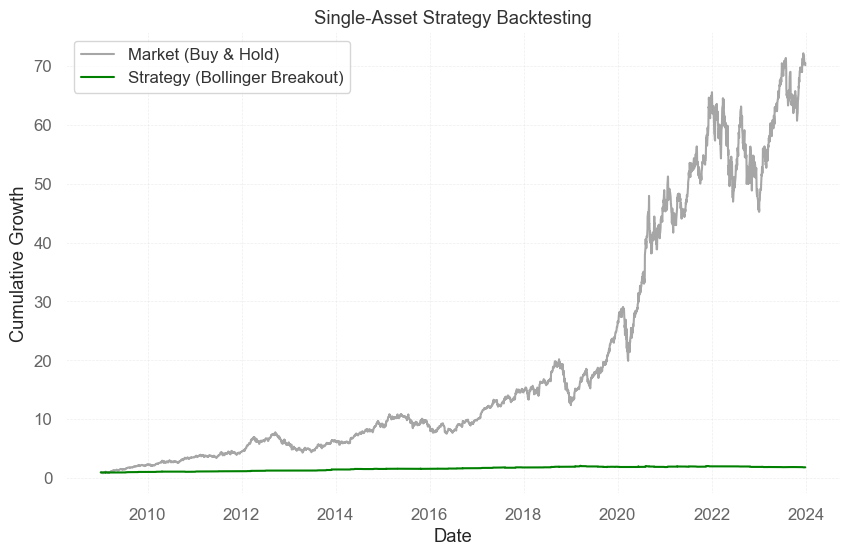

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 1.14
Max Drawdown: -43.80%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,281,070,780,416
Trailing PE: 35.245464
----------------------------------------


In [26]:
#for 1st dataset
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

# 1. Load your single local dataset manually
# (Replace 'my_apple_data.csv' with your current file name)
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')

# Make sure you have your technical indicators calculated (like upper_band)
#df['upper_band'] = ... (your BB code here)
df['upper_band'], df['middle_band'], df['lower_band'] = talib.BBANDS(
    df['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df_results = backtest_bollinger_breakout(df, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

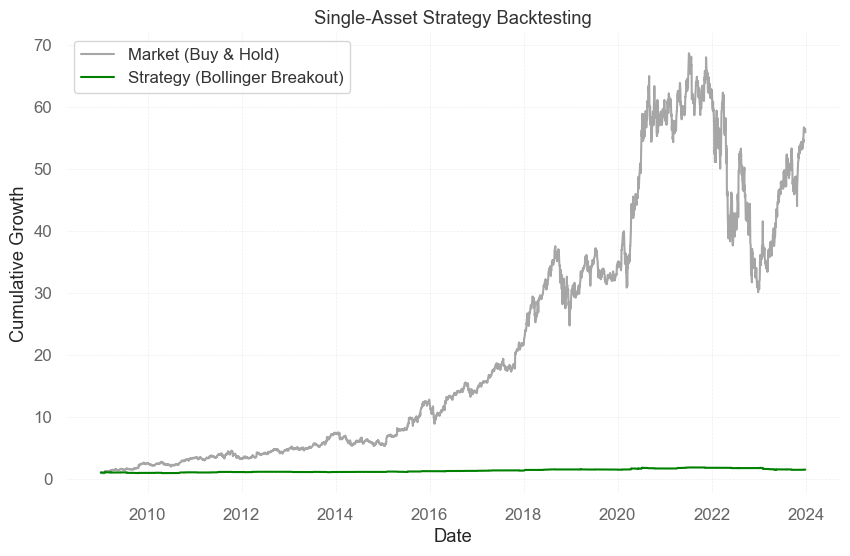

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 1.14
Max Drawdown: -43.80%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,278,867,197,952
Trailing PE: 35.227325
----------------------------------------


In [27]:
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

# 1. Load your single local dataset manually
# (Replace 'my_apple_data.csv' with your current file name)
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')

# Make sure you have your technical indicators calculated (like upper_band)
#df['upper_band'] = ... (your BB code here)
df2['upper_band'], df2['middle_band'], df2['lower_band'] = talib.BBANDS(
    df2['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df2_results = backtest_bollinger_breakout(df2, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

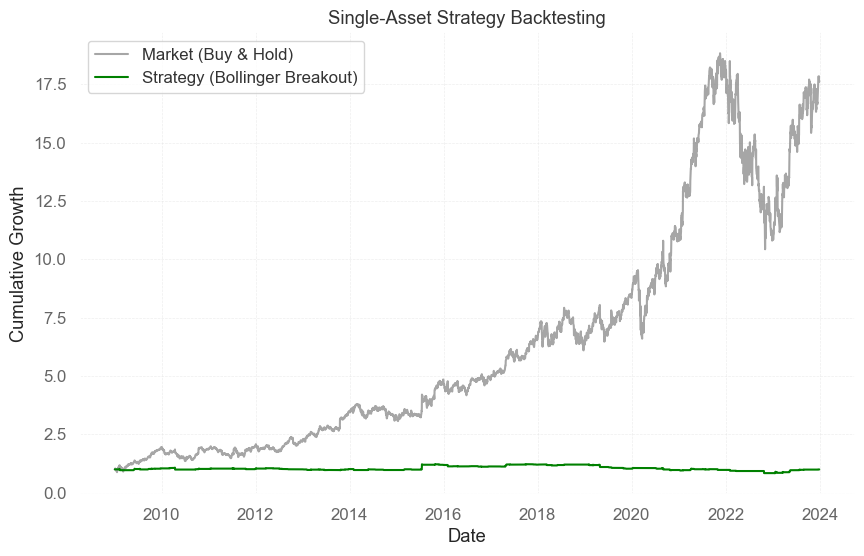

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 0.83
Max Drawdown: -44.60%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,279,454,924,800
Trailing PE: 35.232162
----------------------------------------


In [28]:
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

# 1. Load your single local dataset manually
# (Replace 'my_apple_data.csv' with your current file name)
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')

# Make sure you have your technical indicators calculated (like upper_band)
#df['upper_band'] = ... (your BB code here)
df3['upper_band'], df3['middle_band'], df3['lower_band'] = talib.BBANDS(
    df3['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df3_results = backtest_bollinger_breakout(df3, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df3['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

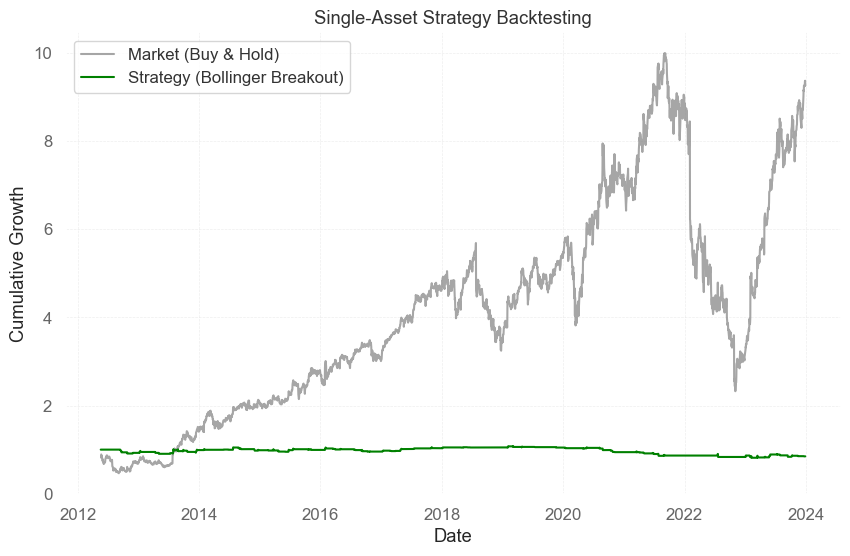

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 0.68
Max Drawdown: -76.74%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,279,014,260,736
Trailing PE: 35.228535
----------------------------------------


In [29]:
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

# 1. Load your single local dataset manually
# (Replace 'my_apple_data.csv' with your current file name)
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')

# Make sure you have your technical indicators calculated (like upper_band)
#df['upper_band'] = ... (your BB code here)
df4['upper_band'], df4['middle_band'], df4['lower_band'] = talib.BBANDS(
    df4['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df4_results = backtest_bollinger_breakout(df4, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df4['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

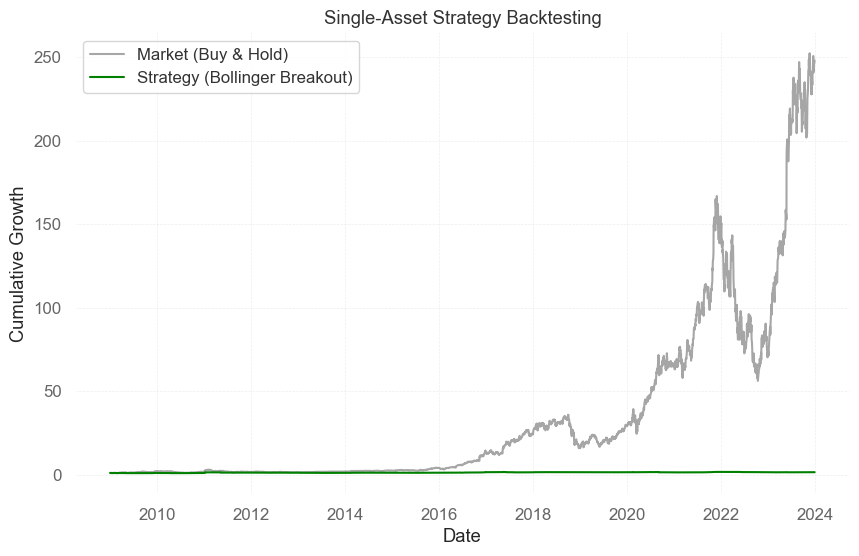

--- Single-Asset Performance Snapshot ---
Sharpe Ratio: 1.14
Max Drawdown: -43.80%
-----------------------------------------
--- Fundamental Snapshot: AAPL ---
Company: Apple Inc.
Market Cap: $4,288,340,819,968
Trailing PE: 35.30532
----------------------------------------


In [30]:
import pandas as pd
import talib
#import analysis as ana  # Import your local analysis.py file

# 1. Load your single local dataset manually
# (Replace 'my_apple_data.csv' with your current file name)
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')

# Make sure you have your technical indicators calculated (like upper_band)
#df['upper_band'] = ... (your BB code here)
df5['upper_band'], df5['middle_band'], df5['lower_band'] = talib.BBANDS(
    df5['Close'].values, 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2, 
    matype=0
)

# 2. Run the single-asset backtest
df5_results = backtest_bollinger_breakout(df5, plot=True)

# 3. Check its QuantStats metrics
generate_performance_report(df['Close'])

# 4. (Optional) Check its fundamental financial profile
print_fundamental_snapshot("AAPL")

Now lets go to visualizing

In [31]:
# ─────────────────────────────────────────────────────────────
# Import our functions from src/
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

from src.Visualization import plot_technical_analysis
#from src.analysis    import compute_sma, compute_rsi, compute_ema, compute_macd, backtest_bollinger_breakout, print_fundamental_snapshot, generate_performance_report

print('Functions imported successfully!')
print()
# You can check what a function does by calling it with ?


Functions imported successfully!



In [36]:
import pandas as pd
#import analysis as ana  # Import your updated analysis.py
import matplotlib as plt


In [40]:
%load_ext autoreload
%autoreload 2

In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


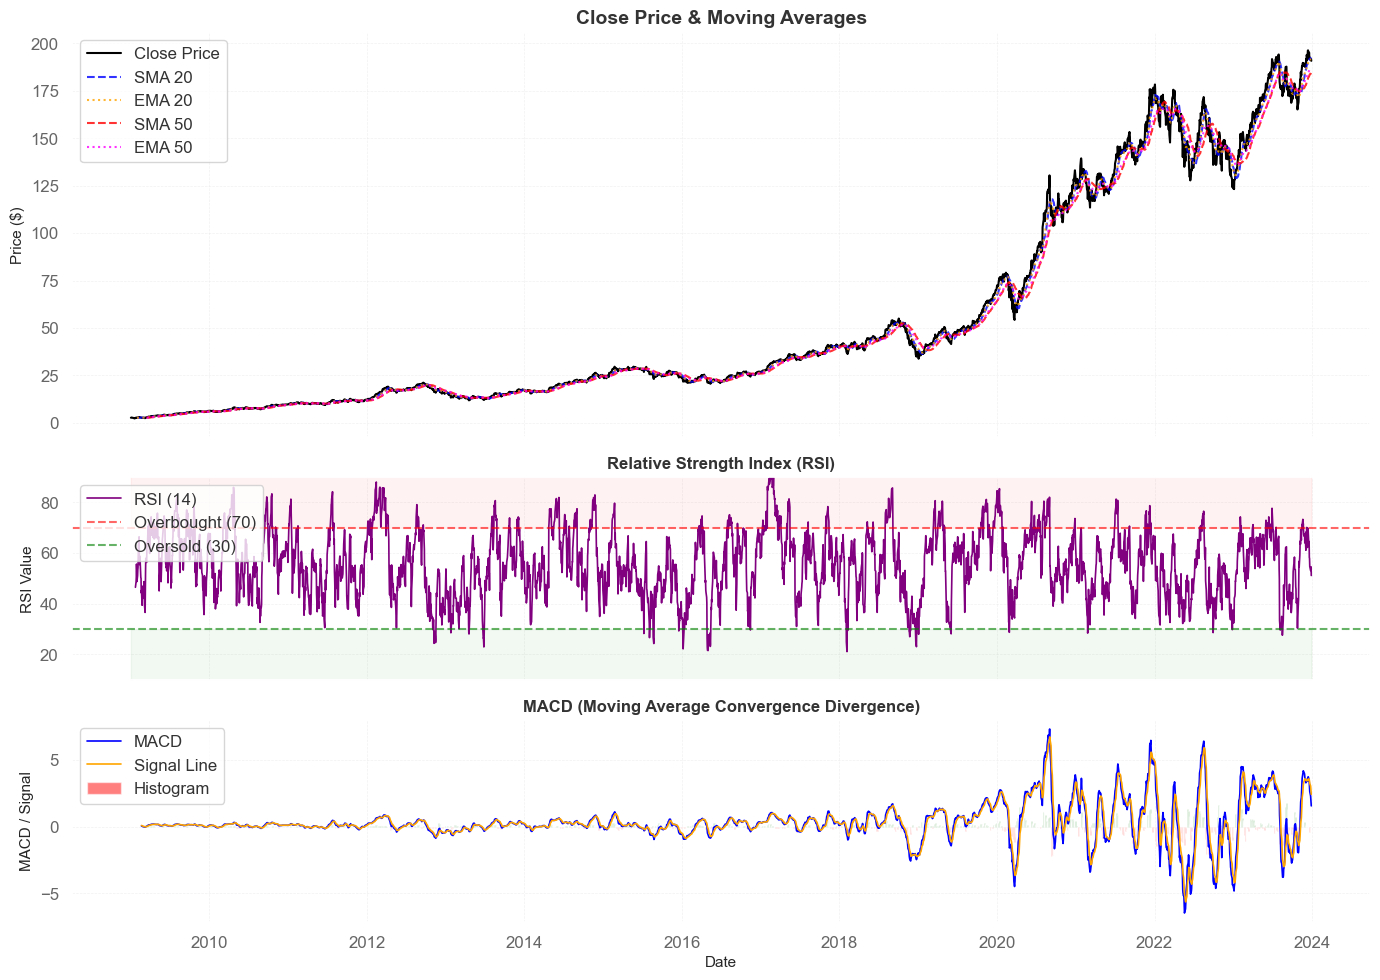

In [46]:
import importlib
import src.Visualization as vis

# Force Python to discard the old cache and read the file fresh from your disk
importlib.reload(vis)

# Now call your function directly from the reloaded module
vis.plot_technical_analysis(df, save_path=None)

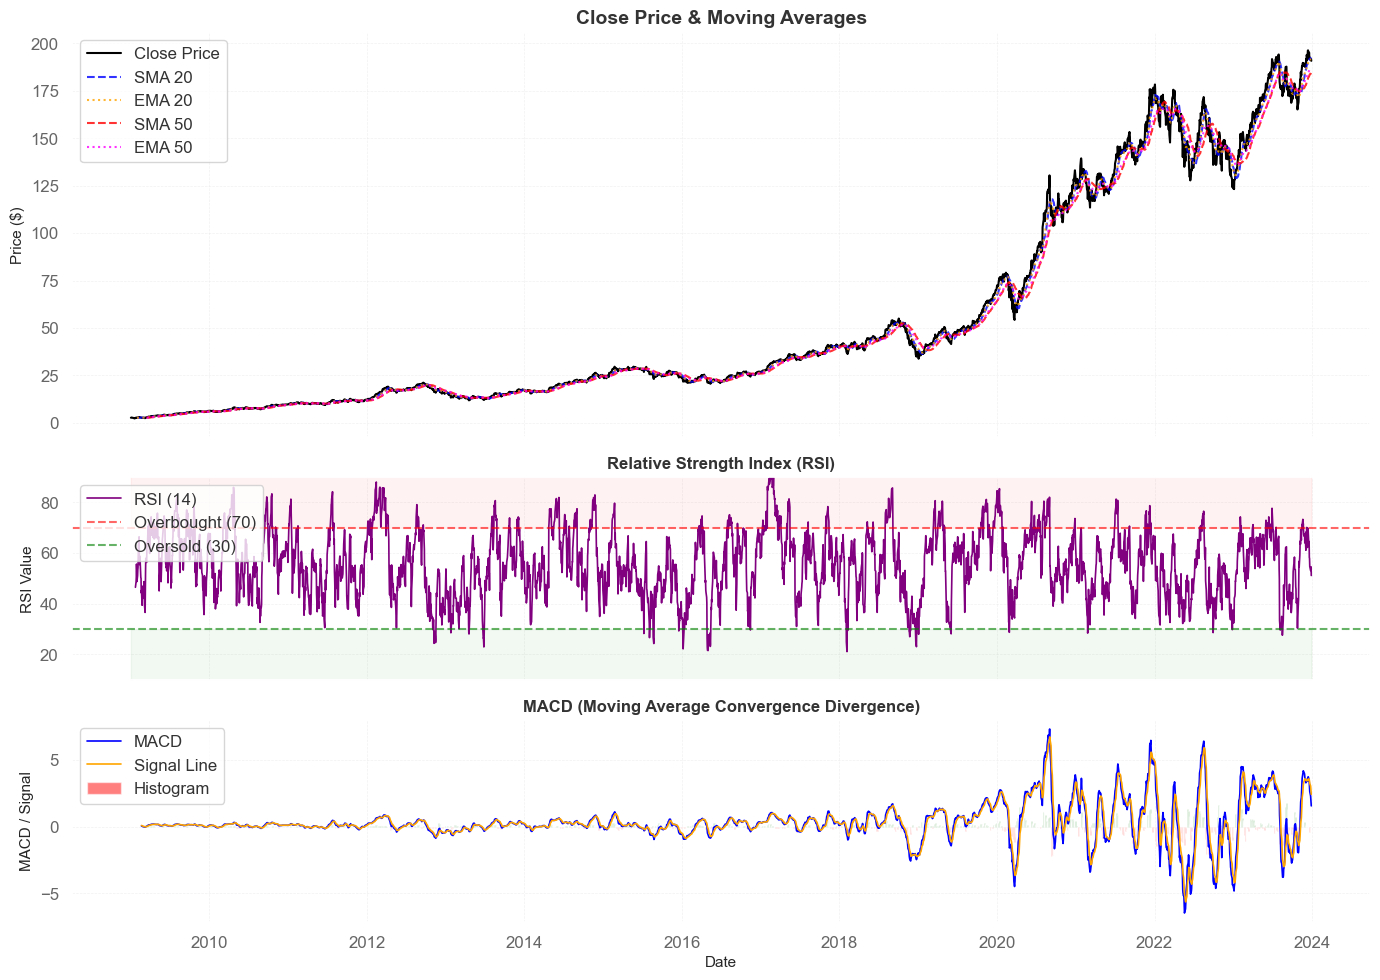

In [47]:
# 1. Load your local dataset manually
#df = pd.read_csv('my_apple_data.csv', parse_dates=['Date'], index_col='Date')
df = df.sort_index()

# 2. Compute 20-Day Indicators
df['SMA_20'] = compute_sma(df['Close'], window=20)
df['EMA_20'] = compute_ema(df['Close'], window=20)

# 3. Compute 50-Day Indicators (NEW)
df['SMA_50'] = compute_sma(df['Close'], window=50)
df['EMA_50'] = compute_ema(df['Close'], window=50)

# 4. Compute RSI and MACD
df['RSI_14'] = compute_rsi(df['Close'], window=14)

macd_data = compute_macd(df['Close'])
df['MACD'] = macd_data['MACD']
df['MACD_Signal'] = macd_data['MACD_Signal']
df['MACD_Hist'] = macd_data['MACD_Hist']

# 5. Call the plotting function
# It will automatically detect 'SMA_50' and 'EMA_50' and draw them!
plot_technical_analysis(df, save_path=None)

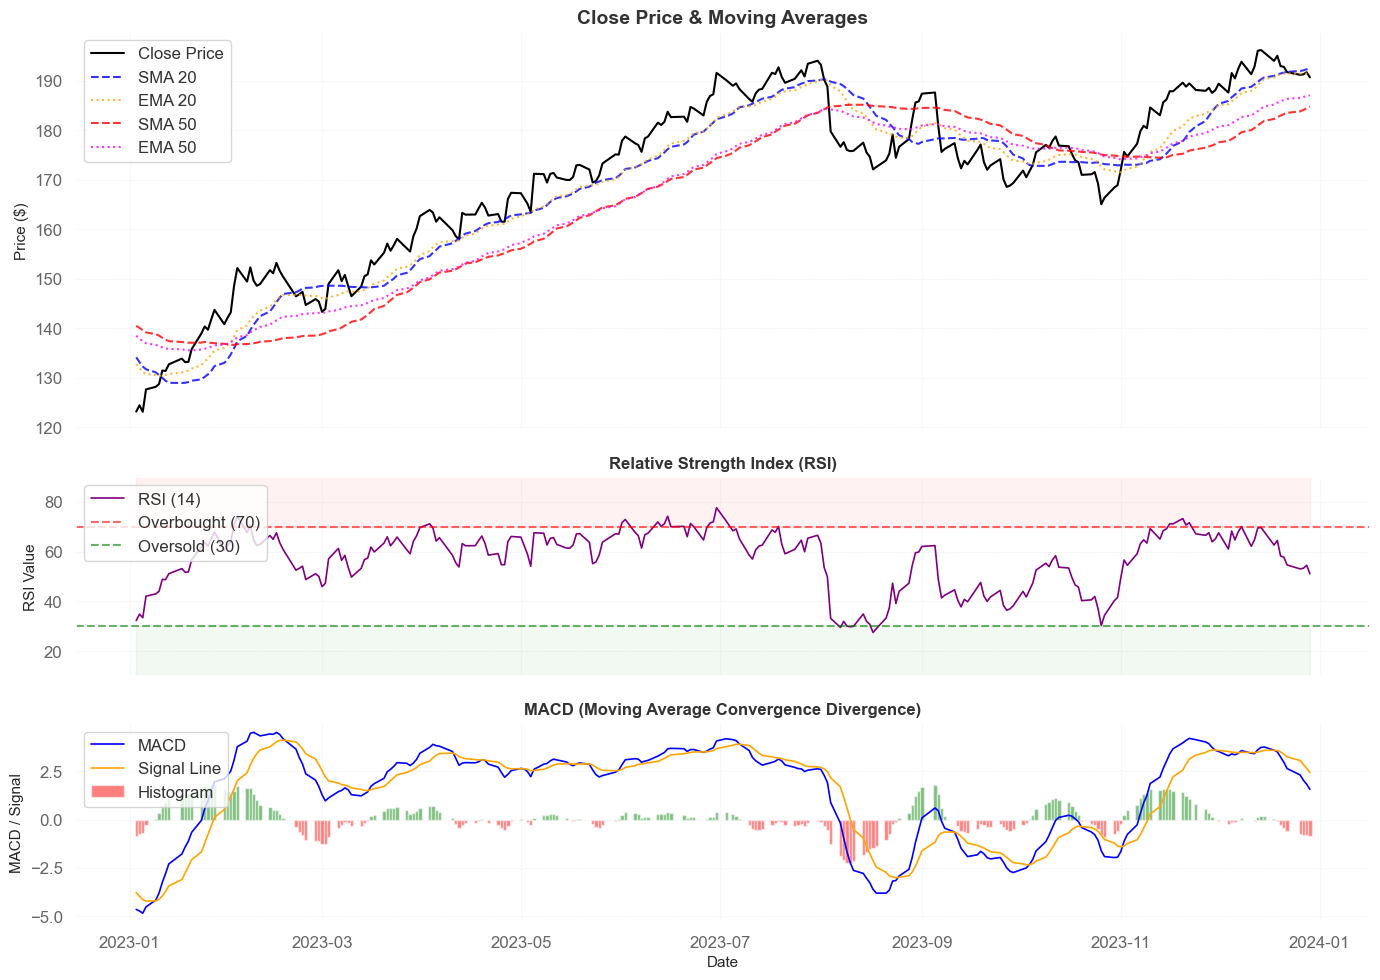

In [49]:
# Filter the data to only show 2023 onwards, then plot
df_zoomed = df.loc['2023-01-01':]

# Call your plotting function on the zoomed data
plot_technical_analysis(df_zoomed, save_path=None)